[**Smart Grid Stability**](https://www.kaggle.com/datasets/pcbreviglieri/smart-grid-stability/data)

This data is a tabular dataset with 60k independent static samples.

In [ ]:
import numpy as np
import pandas as pd
import shutil
from pathlib import Path
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import time
from tqdm import tqdm
import json
import os

import shap
#import lime

from art.estimators.classification.scikitlearn import ScikitlearnRandomForestClassifier
from art.attacks.inference.membership_inference import MembershipInferenceBlackBox
from art.attacks.inference.membership_inference import ShadowModels
from art.utils import to_categorical
from utils.mia_black_box_fi import MembershipInferenceBlackBoxFI
from utils.mia_black_box_XAI import MembershipInferenceBlackBoxXAI
from utils.mia_black_box_only_expl import MembershipInferenceBlackBoxOnlyExpl



import warnings
warnings.filterwarnings("ignore")

In [5]:
dataset_rs = 46

In [6]:
# For downloading dataset
dst_path = Path.cwd() / "input" / "smart-grid-stability"

if not (dst_path / "smart_grid_stability_augmented.csv").exists():

    # Download latest version
    src_path = Path(kagglehub.dataset_download("pcbreviglieri/smart-grid-stability"))
    
    # Destination: current working directory
    
    
    dst_path.mkdir(parents=True, exist_ok=True)
    
    # Copy all files
    for item in src_path.iterdir():
        if item.is_file():
            shutil.copy(item, dst_path / item.name)
    
    print("Dataset copied to:", dst_path)

In [7]:
# Load data
print("Loading file...")
try:
    df_base =pd.read_csv('input/smart-grid-stability/smart_grid_stability_augmented.csv',delimiter=',')
    print(f"✓ Loaded {len(df_base):,} total rows")
except FileNotFoundError as e:
    print(f"✗ Error: File '{e.filename}' not found!")
except Exception as e:
    print(f"✗ Error loading file: {e}")

Loading file...
✓ Loaded 60,000 total rows


In [8]:
# Create a copy for processing to keep the original df_base intact
df_processed = df_base.copy()

#print(df_processed.dtypes)
df_processed.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


[**Grid Stability**](https://www.kaggle.com/code/tahmidmir/smart-grid-stability-with-adversarial-safety#Feature-Engineering)

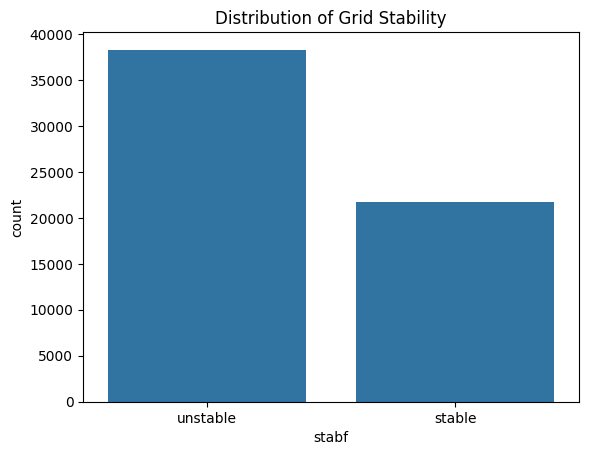

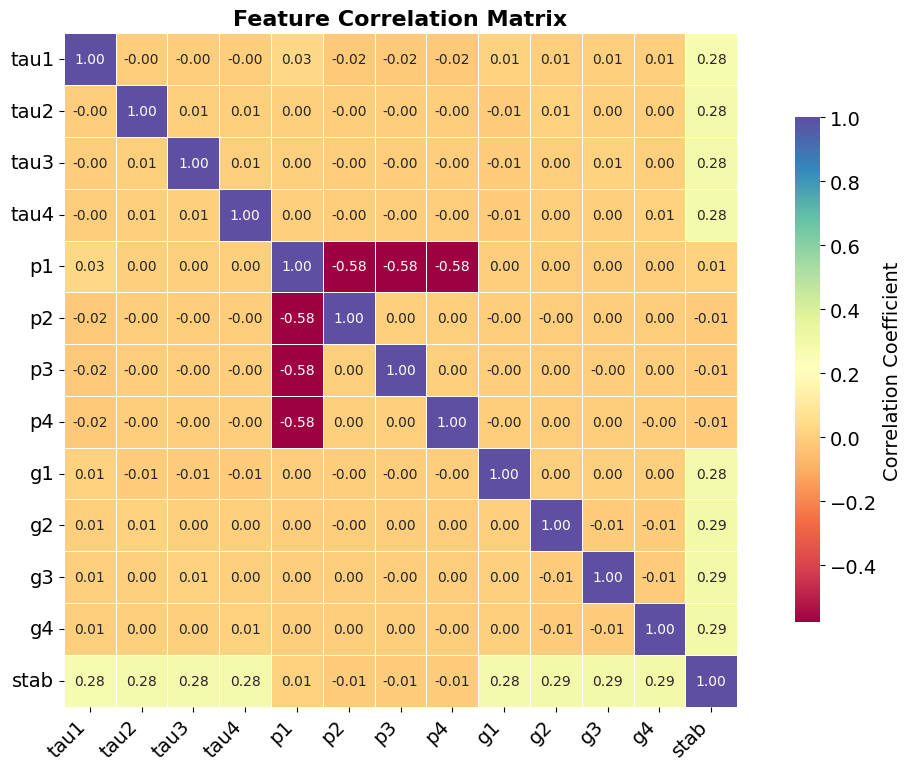

In [9]:
# Check for missing values
df_processed.isnull().sum()

# Visualize the distribution of the target variable
sns.countplot(x='stabf', data=df_processed)
plt.title('Distribution of Grid Stability')
plt.show()

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation = df_processed.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="Spectral",  # 🔥 Vibrant colormap: 'Spectral', 'coolwarm', 'viridis', etc.
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"shrink": 0.75, "label": "Correlation Coefficient"},
    annot_kws={"fontsize": 10}
)
plt.title("Feature Correlation Matrix", fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
print("Cleaning and encoding target...")
df_processed['stabf'] = df_processed['stabf'].map({'unstable': 0, 'stable': 1})
X = df_processed.drop(['stab', 'stabf'], axis=1)
y = df_processed['stabf']
print("✓ Preprocessing done. unstable: 0, stable: 1")

print("\nSplit data: target vs shadow, then train vs test...")
print("75% for shadow, 25% for equal split between training and testing the target model like in the notebook of art")
X_target, X_shadow, y_target, y_shadow = train_test_split(X, y, test_size=0.75, random_state=dataset_rs)
X_train, X_test, y_train, y_test = train_test_split(X_target, y_target, test_size=0.5, random_state=dataset_rs)
X_shadow_a= X_shadow.to_numpy()
y_shadow_a = y_shadow.to_numpy()

Cleaning and encoding target...
✓ Preprocessing done. unstable: 0, stable: 1

Split data: target vs shadow, then train vs test...
75% for shadow, 25% for equal split between training and testing the target model like in the notebook of art


In [11]:
# RANDOM FOREST
def train_target_model(rs):
    """
    :param rs: random state
    :return: trained random forest model
    """
    rf_model = RandomForestClassifier(n_estimators=100, random_state=rs)
    rf_model.fit(X_train, y_train)
    return rf_model

In [12]:
def rf_confusion_matrix(rf_model):
    rf_preds = rf_model.predict(X_test)
    # Custom color maps for variety
    custom_cmaps = [
        sns.light_palette("seagreen", as_cmap=True),
        sns.light_palette("darkorange", as_cmap=True),
        sns.light_palette("royalblue", as_cmap=True)
    ]

    plt.figure(figsize=(18, 5))
    for i, (title, preds, cmap) in enumerate(zip(
        ['Random Forest'],
        [rf_preds],
        custom_cmaps
    )):
        plt.subplot(1, 3, i+1)
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
                    annot_kws={"size": 14, "weight": "bold"})
        plt.title(f'{title} Confusion Matrix', fontsize=18, weight='bold')
        plt.xlabel('Predicted', fontsize=14)
        plt.ylabel('Actual', fontsize=14)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

**XAI**

SHAP

In [13]:
def get_SHAP_explanation(rf_model, rs, dataset_rs):
    """
    Get SHAP explanation of shadow and test data.

    :param rf_model: target model to get explanation on.
    :param rs: random state of the target model, to assign names different models.
    :param dataset_rs: random state for splitting the dataset.
    :return: explainer, value of SHAP explanation on shadow data, value of SHAP explanation on test data
    """
    explanation_path = Path.cwd() / "model_output" / f"explanations_{dataset_rs}" / f"RF-{rs}"
    explanation_path.mkdir(parents=True, exist_ok=True)

    explainer = shap.TreeExplainer(rf_model)

    shadow_file = explanation_path / "X_shadow_on_SHAP.npy"
    test_file = explanation_path / "X_test_on_SHAP.npy"
    train_file = explanation_path / "X_train_on_SHAP.npy"

    if shadow_file.exists():
        print(f"Pre computed shadow explanation for rs={rs}, dataset_rs={dataset_rs} exist. Loading explanation...")
        X_shadow_on_SHAP = np.load(explanation_path / "X_shadow_on_SHAP.npy", allow_pickle=True)
    else:
        print("\nComputing explanation of X_shadow with SHAP...")
        start_time = time.time()
        X_shadow_explained = explainer(X_shadow)
        elapsed_time = time.time() - start_time
        print("✓ Explanation complete.")
        print(f"Elapsed time to explain X_shadow with SHAP: {elapsed_time:.3f} seconds")

        # Explanation values are mirrored in case of binary classification.
        # Only storing explanation of one class without loosing information.
        X_shadow_on_SHAP = X_shadow_explained[:,:,1].values
        np.save(shadow_file, X_shadow_on_SHAP)

        print("Saved explanation of shadow data.")

    if test_file.exists():
        print(f"Pre computed test explanation for rs={rs}, dataset_rs={dataset_rs} exist. Loading explanation...")
        X_test_on_SHAP = np.load(explanation_path / "X_test_on_SHAP.npy", allow_pickle=True)
    else:
        print("Computing explanation of X_test with SHAP...")
        start_time = time.time()
        X_test_explained = explainer(X_test)
        elapsed_time = time.time() - start_time
        print("✓ Explanation complete.")
        print(f"Elapsed time to explain X_test with SHAP: {elapsed_time:.3f} seconds")

        X_test_on_SHAP = X_test_explained[:,:,1].values
        np.save(test_file, X_test_on_SHAP)

        print("\nSaved explanation of test data.")

    if train_file.exists():
        print(f"Pre computed train explanation for rs={rs}, dataset_rs={dataset_rs} exist. Loading explanation...")
        X_train_on_SHAP = np.load(explanation_path / "X_train_on_SHAP.npy", allow_pickle=True)
    else:
        print("Computing explanation of X_train with SHAP...")
        start_time = time.time()
        X_train_explained = explainer(X_train)
        elapsed_time = time.time() - start_time
        print("✓ Explanation complete.")
        print(f"Elapsed time to explain X_train with SHAP: {elapsed_time:.3f} seconds")

        
        X_train_on_SHAP = X_train_explained[:,:,1].values
        np.save(train_file, X_train_on_SHAP)

        print("Saved explanation of train data.")

    print("\n✓ All Explanations ready.")

    return explainer, X_shadow_on_SHAP, X_test_on_SHAP, X_train_on_SHAP

In [ ]:
def visualize_shap(explainer, test_sample):
    shap_values = explainer.shap_values(test_sample)

    shap.initjs()

    # print(shap_values)

    shap.force_plot(
        explainer.expected_value[1],   # base value for class 1
        shap_values[0, :, 1],          # 1D array of 12 SHAP values for class 1
        test_sample                    # shape (1, 12)
    )


'\nplt.figure(figsize=(24, 4))\nshap.force_plot(\n    explainer.expected_value[1],\n    shap_values[0, :, 1],\n    test_sample.round(2),\n    matplotlib=True,\n    show=False,\n    text_rotation=30\n)\nplt.savefig("shap_force_plot.png", dpi=300, bbox_inches="tight")\nplt.close()\n'

LIME

LIME (Local Interpretable Model-Agnostic Explanation) is a local method designed to explain individual predictions and thus very expensive to apply to a large dataset.

Not Implemented, could be experimented on in future work.

In [15]:
"""
# We don't use lime explanation in our experiment, could be experimented with as future work.


explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=['unstable', 'stable'],
    mode='classification'
)
i = 130
exp = explainer_lime.explain_instance(X_test.iloc[i].values, rf_model.predict_proba, num_features=10)
#exp.show_in_notebook()


print(f"Explaining instance {i} with LIME:")
print(f"\nFeature values: {X_test.iloc[i]}")
print(f"\nTrue label: {y_test.iloc[i]}\n")


explanation_list = exp.as_list()
for feature, weight in explanation_list:
    print(f"{feature}: {weight:.3f}")

exp.as_pyplot_figure()
plt.tight_layout()
plt.show()
"""

'\n# We don\'t use lime explanation in our experiment, could be experimented with as future work.\n\n\nexplainer_lime = lime.lime_tabular.LimeTabularExplainer(\n    training_data=X_train.values,\n    feature_names=X.columns.tolist(),\n    class_names=[\'unstable\', \'stable\'],\n    mode=\'classification\'\n)\ni = 130\nexp = explainer_lime.explain_instance(X_test.iloc[i].values, rf_model.predict_proba, num_features=10)\n#exp.show_in_notebook()\n\n\nprint(f"Explaining instance {i} with LIME:")\nprint(f"\nFeature values: {X_test.iloc[i]}")\nprint(f"\nTrue label: {y_test.iloc[i]}\n")\n\n\nexplanation_list = exp.as_list()\nfor feature, weight in explanation_list:\n    print(f"{feature}: {weight:.3f}")\n\nexp.as_pyplot_figure()\nplt.tight_layout()\nplt.show()\n'

[In-built Feature importance](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html)

Forest Trees come with an in-built Feature importance.
Mean Decrease Impurity (MDI/Gini Importance) and Mean Decrease Accuracy (MDA/Permutation Importance) are two primary feature importance metrics in Random Forests.

In [16]:
def rf_fi(rf_model, rs, visualize):
    """
    :param rf_model: trained random forest model
    :param rs: random state the model is trained on
    :param visualize: True for plotting figures
    :return: Feature importance using permutation on full model
    """
    explanation_path = Path.cwd() / "model_output" / "explanations" / f"RF-{rs}"
    explanation_path.mkdir(parents=True, exist_ok=True)
    importances = rf_model.feature_importances_
    std = np.std([rf_model.feature_importances_ for tree in rf_model.estimators_], axis=0)

    feature_names = X.columns
    forest_importances_MDI = pd.Series(importances, index=feature_names)

    if visualize:
        fig, ax = plt.subplots()
        forest_importances_MDI.plot.bar(yerr=std, ax=ax)
        ax.set_title("Feature importances using MDI")
        ax.set_ylabel("Mean decrease in impurity")
        fig.tight_layout()

        plt.rcParams.update({
            'font.size': 16,
            'axes.titlesize': 18,
            'axes.labelsize': 14,
            'xtick.labelsize': 14,
            'ytick.labelsize': 14,
        })
        plt.savefig(explanation_path / "FI_MDI.png")


    
    result = permutation_importance(
        rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
    )

    forest_importances_permutation = pd.Series(result.importances_mean, index=feature_names)

    if visualize:
        fig, ax = plt.subplots()
        forest_importances_permutation.plot.bar(yerr=result.importances_std, ax=ax)
        ax.set_title("Permutation Importance")
        #Feature importances using permutation on full model
        ax.set_ylabel("Mean accuracy decrease")
        fig.tight_layout()
        plt.rcParams.update({
                    'font.size': 16,
                    'axes.titlesize': 18,
                    'axes.labelsize': 14,
                    'xtick.labelsize': 14,
                    'ytick.labelsize': 14,
                })
        plt.savefig(explanation_path / "FI_permutation.png")
        plt.show()

    return forest_importances_permutation


**Membership Inference Attack**

Black-Box Membership Inference Attack on [Shadow Model (RF)](https://github.com/Trusted-AI/adversarial-robustness-toolbox/blob/main/notebooks/attack_membership_inference_shadow_models.ipynb)

In [17]:
def bb_shadow_mia(art_classifier, rs, X_shadow_a = X_shadow_a, y_shadow_a = y_shadow_a, X_train = X_train, y_train = y_train, X_test = X_test, y_test = y_test):
    """
    :param art_classifier: target model wrapped in Art classifier
    :param rs: random state for the shadow models
    :return: attack member accuracy, attack non-member accuracy, combined attack accuracy, member infer, nonmember infer, shadow model accuracies,
        member infer probabilities, nonmember infer probabilities
    """
    # print("\nOriginal Black-Box Membership Inference Attack on Shadow Model:")
    #print("\nTraining Shadow Model...")

    shadow_models = ShadowModels(art_classifier, num_shadow_models=3, random_state=rs)
    
    # print("Generate Shadow Dataset...")
    shadow_dataset = shadow_models.generate_shadow_dataset(X_shadow_a, to_categorical(y_shadow_a, 2))
    (member_x, member_y, member_predictions), (nonmember_x, nonmember_y, nonmember_predictions) = shadow_dataset

    # Shadow models' accuracy
    sm_acc = [sm.model.score(X_test, y_test) for sm in shadow_models.get_shadow_models()]

    # print("\nRunning black-box membership inference attack on the meta-dataset generated using the shadow models")
    attack = MembershipInferenceBlackBox(art_classifier, attack_model_type="rf")
    attack.fit(member_x, member_y, nonmember_x, nonmember_y, member_predictions, nonmember_predictions)

    member_infer = attack.infer(X_train, y_train)
    nonmember_infer = attack.infer(X_test, y_test)
    member_infer_prob = attack.infer(X_train, y_train, probability=True)
    nonmember_infer_prob = attack.infer(X_test, y_test, probability=True)
    member_acc = np.sum(member_infer) / len(X_train)
    nonmember_acc = 1 - np.sum(nonmember_infer) / len(X_test)
    acc = (member_acc * len(X_train) + nonmember_acc * len(X_test)) / (len(X_train) + len(X_test))

    return {
        "member_acc": member_acc,
        "nonmember_acc": nonmember_acc,
        "acc": acc,
        "member_infer": member_infer,
        "nonmember_infer": nonmember_infer,
        "sm_acc": sm_acc,
        "attack": attack,
        "member_infer_prob": member_infer_prob,
        "nonmember_infer_prob": nonmember_infer_prob
    }

In [18]:
def calc_precision_recall(predicted, actual, positive_value=1):
    score = 0  # both predicted and actual are positive
    num_positive_predicted = 0  # predicted positive
    num_positive_actual = 0  # actual positive
    for i in range(len(predicted)):
        if predicted[i] == positive_value:
            num_positive_predicted += 1
        if actual[i] == positive_value:
            num_positive_actual += 1
        if predicted[i] == actual[i]:
            if predicted[i] == positive_value:
                score += 1
    
    if num_positive_predicted == 0:
        precision = 1
    else:
        precision = score / num_positive_predicted  # the fraction of predicted “Yes” responses that are correct
    if num_positive_actual == 0:
        recall = 1
    else:
        recall = score / num_positive_actual  # the fraction of “Yes” responses that are predicted correctly

    return precision, recall

Shadow and Attack Model trained only on explanations (SHAP values)

In [19]:
def bb_shadow_mia_on_SHAP(art_classifier, rs, X_shadow_on_SHAP, X_test_on_SHAP, X_train_on_SHAP, y_shadow_a = y_shadow_a, y_train = y_train, y_test = y_test):
    """
    :param art_classifier: target model wrapped in Art classifier
    :param rs: random state for the shadow models
    :param X_shadow_on_SHAP: X_shadow explained with SHAP
    :X_test_on_SHAP: X_test explained with SHAP
    :return: attack member accuracy, attack non-member accuracy, combined attack accuracy, member infer, nonmember infer; on SHAP exaplantion
        member_infer_on_SHAP_prob, nonmember_infer_on_SHAP_prob
    """

    shadow_models_on_SHAP = ShadowModels(art_classifier, num_shadow_models=3, random_state=rs)

    # Generate Shadow Dataset on only SHAP explanations
    shadow_dataset_on_SHAP = shadow_models_on_SHAP.generate_shadow_dataset(X_shadow_on_SHAP, to_categorical(y_shadow_a, 2))
    (member_x_on_SHAP, member_y_on_SHAP, member_predictions_on_SHAP), (nonmember_x_on_SHAP, nonmember_y_on_SHAP, nonmember_predictions_on_SHAP) = shadow_dataset_on_SHAP

    sm_acc_on_SHAP =[sm.model.score(X_test_on_SHAP, y_test) for sm in shadow_models_on_SHAP.get_shadow_models()]

    attack_on_SHAP = MembershipInferenceBlackBoxOnlyExpl(art_classifier, attack_model_type="rf")
    attack_on_SHAP.fit(member_x_on_SHAP, member_y_on_SHAP, nonmember_x_on_SHAP, nonmember_y_on_SHAP)

    member_infer_on_SHAP = attack_on_SHAP.infer(X_train_on_SHAP, y_train)
    nonmember_infer_on_SHAP = attack_on_SHAP.infer(X_test_on_SHAP, y_test)
    member_infer_prob_on_SHAP = attack_on_SHAP.infer(X_train_on_SHAP, y_train, probabilities=True)
    nonmember_infer_prob_on_SHAP = attack_on_SHAP.infer(X_test_on_SHAP, y_test, probabilities=True)
    member_acc_on_SHAP = np.sum(member_infer_on_SHAP) / len(X_train_on_SHAP)
    nonmember_acc_on_SHAP = 1 - np.sum(nonmember_infer_on_SHAP) / len(X_test_on_SHAP)
    acc_on_SHAP = (member_acc_on_SHAP * len(X_train_on_SHAP) + nonmember_acc_on_SHAP * len(X_test_on_SHAP)) / (len(X_train_on_SHAP) + len(X_test_on_SHAP))

    return {
        "member_acc_on_SHAP": member_acc_on_SHAP,
        "nonmember_acc_on_SHAP": nonmember_acc_on_SHAP,
        "acc_on_SHAP": acc_on_SHAP,
        "member_infer_on_SHAP": member_infer_on_SHAP,
        "nonmember_infer_on_SHAP": nonmember_infer_on_SHAP,
        "sm_acc_on_SHAP": sm_acc_on_SHAP,
        "attack_on_SHAP": attack_on_SHAP,
        "member_infer_prob_on_SHAP": member_infer_prob_on_SHAP,
        "nonmember_infer_prob_on_SHAP": nonmember_infer_prob_on_SHAP
    }

    

Membership Inference Attack on Shadow Model (RF) trained on output probabilities concatenated with explanations (SHAP values) as features.

In [20]:
def bb_shadow_mia_with_SHAP(art_classifier, rs, X_shadow_on_SHAP, X_test_on_SHAP, X_train_on_SHAP, X_shadow_a = X_shadow_a, y_shadow_a = y_shadow_a, X_train = X_train, y_train = y_train, X_test = X_test, y_test = y_test):
    """
    :param art_classifier: target model wrapped in Art classifier
    :param rs: random state for the shadow models
    :param X_shadow_on_SHAP: X_shadow explained with SHAP
    :param X_test_on_SHAP: X_test explained with SHAP
    :param dataset_rs: random state for splitting the initial dataset
    :return: attack member accuracy, attack non-member accuracy, combined attack accuracy, member infer, nonmember infer; shadow model accuracy with SHAP explanation
    """

    
    # For creating the dataset to train the shadow models without explanation information to get clean probability output
    shadow_models_plain_SHAP = ShadowModels(art_classifier, num_shadow_models=3, random_state=rs)
    shadow_dataset = shadow_models_plain_SHAP.generate_shadow_dataset(X_shadow_a, to_categorical(y_shadow_a, 2))
    (member_x, member_y, member_predictions), (nonmember_x, nonmember_y, nonmember_predictions) = shadow_dataset


    # For creating the dataset with explanation for attack (the indices list will be the same)
    shadow_models_with_SHAP = ShadowModels(art_classifier, num_shadow_models=3, random_state=rs)
    # Concatenate original features with SHAP explanations for attack model
    # X_shadow_with_SHAP = np.concatenate([X_shadow_a, X_shadow_on_SHAP], axis=1)

    # Use generate_shadow_dataset to get the same shadow data split as the one without SHAP explanation
    shadow_dataset_on_SHAP = shadow_models_with_SHAP.generate_shadow_dataset(X_shadow_on_SHAP, to_categorical(y_shadow_a, 2))
    (member_x_on_SHAP, member_y_on_SHAP, member_predictions_on_SHAP), (nonmember_x_on_SHAP, nonmember_y_on_SHAP, nonmember_predictions_on_SHAP) = shadow_dataset_on_SHAP
    

    X_test_with_SHAP = np.concatenate([X_test.values, X_test_on_SHAP], axis=1)
    X_train_with_SHAP = np.concatenate([X_train.values, X_train_on_SHAP], axis=1)

    # Shadow models' accuracy (should be the same as the shadow models in the basic attack)
    sm_acc_plain_SHAP = [sm.model.score(X_test, y_test) for sm in shadow_models_plain_SHAP.get_shadow_models()]

    # art_classifier,
    attack_with_SHAP = MembershipInferenceBlackBoxXAI(art_classifier, attack_model_type="rf")
    # X will be concatenated with SHAP explanation, prediction will be based on original feature without SHAP explanation
    # input explanations as well
    attack_with_SHAP.fit(member_x, member_y, nonmember_x, nonmember_y, member_predictions, nonmember_predictions, member_x_on_SHAP, nonmember_x_on_SHAP)
    


    member_infer_with_SHAP = attack_with_SHAP.infer(X_train, y_train, X_train_on_SHAP)
    nonmember_infer_with_SHAP = attack_with_SHAP.infer(X_test, y_test, X_test_on_SHAP)
    member_infer_prob_with_SHAP = attack_with_SHAP.infer(X_train, y_train, X_train_on_SHAP, probabilities=True)
    nonmember_infer_prob_with_SHAP = attack_with_SHAP.infer(X_test, y_test, X_test_on_SHAP, probabilities=True)
    member_acc_with_SHAP = np.sum(member_infer_with_SHAP) / len(X_train_with_SHAP)
    nonmember_acc_with_SHAP = 1 - np.sum(nonmember_infer_with_SHAP) / len(X_test_with_SHAP)
    acc_with_SHAP = (member_acc_with_SHAP * len(X_train_with_SHAP) + nonmember_acc_with_SHAP * len(X_test_with_SHAP)) / (len(X_train_with_SHAP) + len(X_test_with_SHAP))

    return {
        "member_acc_with_SHAP": member_acc_with_SHAP,
        "nonmember_acc_with_SHAP": nonmember_acc_with_SHAP,
        "acc_with_SHAP": acc_with_SHAP,
        "member_infer_with_SHAP": member_infer_with_SHAP,
        "nonmember_infer_with_SHAP": nonmember_infer_with_SHAP,
        "sm_acc_with_SHAP": sm_acc_plain_SHAP,
        "attack_with_SHAP": attack_with_SHAP,
        "member_infer_prob_with_SHAP": member_infer_prob_with_SHAP,
        "nonmember_infer_prob_with_SHAP": nonmember_infer_prob_with_SHAP
    }

Membership Inference Attack (with Feature Importance)

In [22]:
def bb_shadow_mia_FI(art_classifier, rs, forest_importances_permutation, X_shadow_a = X_shadow_a, y_shadow_a = y_shadow_a, X_train = X_train, y_train = y_train, X_test = X_test, y_test = y_test):
    """
    :param art_classifier: target model wrapped in Art classifier
    :param rs: random state for the shadow models
    :return: attack member accuracy, attack non-member accuracy, combined attack accuracy, member infer, nonmember infer; with Feature Importance
    """
    forest_importances_permutation_i = forest_importances_permutation.reset_index(drop=True)

    threshold = 1/(X.shape[1]*1.5)
    fi_dropped = forest_importances_permutation_i[forest_importances_permutation_i >= threshold]
    feature_list = fi_dropped.index.tolist()

    X_shadow_fi = X_shadow_a[:, feature_list]
    X_test_fi = X_test.to_numpy()[:, feature_list]

    print(f"X_shadow_fi shape: {X_shadow_fi.shape}, X_test_fi shape: {X_test_fi.shape}, dropped features: {len(feature_list)}")


    # Black-Box Membership Inference Attack on Shadow Model with dropped features according to feature importance
    shadow_models_fi = ShadowModels(art_classifier, num_shadow_models=3, random_state=rs)

    shadow_dataset_fi = shadow_models_fi.generate_shadow_dataset(X_shadow_fi, to_categorical(y_shadow_a, 2))
    (member_x_fi, member_y_fi, member_predictions_fi), (nonmember_x_fi, nonmember_y_fi, nonmember_predictions_fi) = shadow_dataset_fi

    print("member_x_fi shape:", member_x_fi.shape)

    # Shadow models' accuracy
    sm_acc_fi = [sm.model.score(X_test_fi, y_test) for sm in shadow_models_fi.get_shadow_models()]


    attack_fi = MembershipInferenceBlackBoxFI(art_classifier, attack_model_type="rf")
    attack_fi.fit(member_x_fi, member_y_fi, nonmember_x_fi, nonmember_y_fi, member_predictions_fi, nonmember_predictions_fi)

    print("X_train shape:", X_train.shape)

    member_infer_fi = attack_fi.infer(X_train, y_train)
    nonmember_infer_fi = attack_fi.infer(X_test, y_test)
    member_acc_fi = np.sum(member_infer_fi) / len(X_train)
    nonmember_acc_fi = 1 - np.sum(nonmember_infer_fi) / len(X_test)
    member_infer_prob_fi = attack_fi.infer(X_train, y_train, probabilities=True)
    nonmember_infer_prob_fi = attack_fi.infer(X_test, y_test, probabilities=True)
    acc_fi = (member_acc_fi * len(X_train) + nonmember_acc_fi * len(X_test)) / (len(X_train) + len(X_test))

    return {
        "member_acc_fi": member_acc_fi,
        "nonmember_acc_fi": nonmember_acc_fi,
        "acc_fi": acc_fi,
        "member_infer_fi": member_infer_fi,
        "nonmember_infer_fi": nonmember_infer_fi,
        "sm_acc_fi": sm_acc_fi,
        "feature_list": feature_list,
        "attack_fi": attack_fi,
        "member_infer_prob_fi": member_infer_prob_fi,
        "nonmember_infer_prob_fi": nonmember_infer_prob_fi
    }

In [23]:
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    else:
        return obj

In [ ]:
"""
:param rs_list: list of random state, also used as identification of the run
:param visualize: fine granular visualization of each step. Turn off to declutter output
:param dataset_rs: random state for splitting the dataset
"""
#rs_list = list(range(42, 45))
rs_list = list(range(0, 1))
visualize = False
results_path = Path.cwd() / "model_output" / "MIA" / f"results_rf_{dataset_rs}.json"
tmp_path = results_path.with_suffix(".tmp")

# Load existing data (if any)
if os.path.exists(results_path):
    print(f"Existing results found at {results_path}. Loading data...")
    with open(results_path, "r") as f:
        data = json.load(f)
else:
    print("No existing results found. Starting fresh.")
    results_path.parent.mkdir(parents=True, exist_ok=True)
    data = []

for current_run in tqdm(rs_list):
    rs = current_run

    # check whether the run is already saved in the results csv file, if yes, skip the run
    if any(result['run'] == current_run for result in data):
        print(f"Run {current_run} already exists. Skipping...")
        continue

    rf_model = train_target_model(rs)

    if visualize:
        rf_preds = rf_model.predict(X_test)
        print("\nRandom Forest Accuracy:", accuracy_score(y_test, rf_preds))
        print("\n", classification_report(y_test, rf_preds))
        rf_confusion_matrix(rf_model)

    explainer, X_shadow_on_SHAP, X_test_on_SHAP, X_train_on_SHAP = get_SHAP_explanation(rf_model, rs, dataset_rs)
    if visualize:
        test_sample = X_test.iloc[[0]]
        visualize_shap(explainer, test_sample)

    forest_importances_permutation = rf_fi(rf_model, rs, visualize)

    art_classifier = ScikitlearnRandomForestClassifier(rf_model)
    baseline_acc = rf_model.score(X_test, y_test)
    if visualize:
        print('Base Random Forest model accuracy: ', baseline_acc)

    # Membership Inference Attacks
    if visualize:
        print("\nOriginal Black-Box Membership Inference Attack on Shadow Model:")

    results_bb_shadow_mia = bb_shadow_mia(art_classifier, rs)

    if visualize:
        print('\nShadow Models accuracy:', results_bb_shadow_mia["sm_acc"])
        print('\nAttack Member Acc:', results_bb_shadow_mia["member_acc"])
        print('Attack Non-Member Acc:', results_bb_shadow_mia["nonmember_acc"])
        print('Attack Accuracy:', results_bb_shadow_mia["acc"])

        print("\nPrecision, Recall:", calc_precision_recall(np.concatenate((results_bb_shadow_mia["member_infer"], results_bb_shadow_mia["nonmember_infer"])), 
                                np.concatenate((np.ones(len(results_bb_shadow_mia["member_infer"])), np.zeros(len(results_bb_shadow_mia["nonmember_infer"]))))))
           
    if visualize:
        print("\nBlack-Box Membership Inference Attack on Shadow Model using only SHAP explantion:")

    results_bb_shadow_mia_on_SHAP = bb_shadow_mia_on_SHAP(art_classifier, rs, X_shadow_on_SHAP, X_test_on_SHAP, X_train_on_SHAP)

    if visualize:
        print('\nAttack Member on SHAP Acc:', results_bb_shadow_mia_on_SHAP["member_acc_on_SHAP"])
        print('Attack Non-Member on SHAP Acc:', results_bb_shadow_mia_on_SHAP["nonmember_acc_on_SHAP"])
        print('Attack on SHAP Accuracy:', results_bb_shadow_mia_on_SHAP["acc_on_SHAP"])

    if visualize:
        print("\nBlack-Box Membership Inference Attack on Shadow Model with SHAP explanation:")

    results_bb_shadow_mia_with_SHAP = bb_shadow_mia_with_SHAP(art_classifier, rs, X_shadow_on_SHAP, X_test_on_SHAP, X_train_on_SHAP)

    if visualize:
        print('\nAttack Member with SHAP Acc:', results_bb_shadow_mia_with_SHAP["member_acc_with_SHAP"])
        print('Attack Non-Member with SHAP Acc:', results_bb_shadow_mia_with_SHAP["nonmember_acc_with_SHAP"])
        print('Attack with SHAP Accuracy:', results_bb_shadow_mia_with_SHAP["acc_with_SHAP"])

    if visualize:
        print("\nBlack-Box Membership Inference Attack on Shadow Model with dropped features according to feature importance:")

    results_bb_shadow_mia_FI = bb_shadow_mia_FI(art_classifier, rs, forest_importances_permutation)

    if visualize:
        print('\nFeatures used in FI attack:', results_bb_shadow_mia_FI["feature_list"])
        print('\nAttack Member FI Acc:', results_bb_shadow_mia_FI["member_acc_fi"])
        print('Attack Non-Member FI Acc:', results_bb_shadow_mia_FI["nonmember_acc_fi"])
        print('Attack FI Accuracy:', results_bb_shadow_mia_FI["acc_fi"])
        
    

    # save the results in a json file
    new_result = {
        "run": current_run,
        "baseline": baseline_acc,
        "attacks": {
            "results_bb_shadow_mia": {
                "member_acc": results_bb_shadow_mia["member_acc"],
                "nonmember_acc": results_bb_shadow_mia["nonmember_acc"],
                "acc": results_bb_shadow_mia["acc"],
                "member_infer": results_bb_shadow_mia["member_infer"],
                "nonmember_infer": results_bb_shadow_mia["nonmember_infer"],
                "member_infer_prob": results_bb_shadow_mia["member_infer_prob"],
                "nonmember_infer_prob": results_bb_shadow_mia["nonmember_infer_prob"],
                "shadow_models_acc": results_bb_shadow_mia["sm_acc"]
            },
            "results_bb_shadow_mia_on_SHAP": {
                "member_acc": results_bb_shadow_mia_on_SHAP["member_acc_on_SHAP"],
                "nonmember_acc": results_bb_shadow_mia_on_SHAP["nonmember_acc_on_SHAP"],
                "acc": results_bb_shadow_mia_on_SHAP["acc_on_SHAP"],
                "member_infer": results_bb_shadow_mia_on_SHAP["member_infer_on_SHAP"],
                "nonmember_infer": results_bb_shadow_mia_on_SHAP["nonmember_infer_on_SHAP"],
                "member_infer_prob": results_bb_shadow_mia_on_SHAP["member_infer_prob_on_SHAP"],
                "nonmember_infer_prob": results_bb_shadow_mia_on_SHAP["nonmember_infer_prob_on_SHAP"],
                "shadow_models_acc": results_bb_shadow_mia_on_SHAP["sm_acc_on_SHAP"]
            },
            "results_bb_shadow_mia_with_SHAP": {
                "member_acc": results_bb_shadow_mia_with_SHAP["member_acc_with_SHAP"],
                "nonmember_acc": results_bb_shadow_mia_with_SHAP["nonmember_acc_with_SHAP"],
                "acc": results_bb_shadow_mia_with_SHAP["acc_with_SHAP"],
                "member_infer": results_bb_shadow_mia_with_SHAP["member_infer_with_SHAP"],
                "nonmember_infer": results_bb_shadow_mia_with_SHAP["nonmember_infer_with_SHAP"],
                "member_infer_prob": results_bb_shadow_mia_with_SHAP["member_infer_prob_with_SHAP"],
                "nonmember_infer_prob": results_bb_shadow_mia_with_SHAP["nonmember_infer_prob_with_SHAP"],
                "shadow_models_acc": results_bb_shadow_mia_with_SHAP["sm_acc_with_SHAP"]
            },
            "results_bb_shadow_mia_FI": {
                "member_acc": results_bb_shadow_mia_FI["member_acc_fi"],
                "nonmember_acc": results_bb_shadow_mia_FI["nonmember_acc_fi"],
                "acc": results_bb_shadow_mia_FI["acc_fi"],
                "member_infer": results_bb_shadow_mia_FI["member_infer_fi"],
                "nonmember_infer": results_bb_shadow_mia_FI["nonmember_infer_fi"],
                "member_infer_prob": results_bb_shadow_mia_FI["member_infer_prob_fi"],
                "nonmember_infer_prob": results_bb_shadow_mia_FI["nonmember_infer_prob_fi"],
                "shadow_models_acc": results_bb_shadow_mia_FI["sm_acc_fi"],
                "feature_list": results_bb_shadow_mia_FI["feature_list"]
            },
        }
    }
    data.append(make_json_safe(new_result))

    print(f"Run {current_run} saved.")

    with open(tmp_path, "w") as f:
        json.dump(data, f, indent=2)

    os.replace(tmp_path, results_path)

# final cleanup step
data = sorted(data, key=lambda x: x["run"])

tmp_path = results_path.parent / (results_path.stem + ".tmp.json")

with open(tmp_path, "w") as f:
    json.dump(data, f, indent=2)

os.replace(tmp_path, results_path)

print(f"All runs completed. Final results saved to {results_path}.")